## 리텐션이 높은 코호트의 특징 분석
### 가설 설정

앞서 분석을 통해 리텐션이 높은 코호트는 단순히 평균 값이 높은 것이 아니라,  
여러 Range 구간에 걸쳐 **재구매 패턴이 지속적으로 나타나는 특징**을 보였다.

| 순위 | 코호트(첫 구매 기준) | R1 | R2 | R3 | R4 | 평균 리텐션 | 전체 평균 대비 |
|------|--------|-----|-----|-----|-----|------------|---------------|
| 1위 | 2024-05 | 10.6% | 10.9% | - | - | **10.75%** | **+36.1%** |
| 2위 | 2024-03 | 10.9% | 9.6% | 9.6% | - | **10.01%** | **+26.7%** |
| - | 전체 평균 | - | - | - | - | 7.90% | - |

이러한 차이는 고객의 구매 행동, 가격 민감도, 상품 선호도 등의 요인에서 기인할 가능성이 있다.  
따라서 본 분석에서는 리텐션 차이를 설명할 수 있는 주요 요인을 다음과 같은 가설을 통해 검증하고자 한다.

### **가설3. 리텐션이 높은 코호트가 많이 구매한 품목 카테고리 비율은 전체 코호트와 상이할 것이다.**  
→ 특정 상품 카테고리는 반복 구매 성향이 강할 수 있으며, 이러한 상품을 구매한 고객이 높은 리텐션을 보일 가능성이 있다.

In [1]:
import pandas as pd
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os

load_dotenv()  # .env 파일 로드

# MySQL 연결
engine = create_engine(
    f"mysql+mysqlconnector://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}/{os.getenv('DB_NAME')}"
)


# 2024년 전체 카테고리별 구매 횟수 테이블
query_2024 = """
WITH first_purchase AS (
	SELECT 
		CustomerID,
        MIN(OrderDate) AS first_purchase_date,
        DATE_FORMAT(MIN(OrderDate), "%Y-%m") AS first_purchase_month
	FROM orders_info
    GROUP BY CustomerID
),

first_purchase_2024 AS (
	SELECT 
		CustomerID,
        first_purchase_month
    FROM first_purchase
    WHERE YEAR(first_purchase_date) = 2024
)

SELECT 
	o.Category,
    COUNT(*) AS orders_cnt_2024
FROM first_purchase_2024 f24
JOIN orders_info o ON o.CustomerID = f24.CustomerID
GROUP BY o.Category
ORDER BY orders_cnt_2024 DESC;
"""


# 2024년 리텐션이 높은 그룹의 각 카테고리별 구매 횟수 테이블 
query_2024_high_retention = """
WITH first_purchase AS (
    SELECT
        CustomerID,
        MIN(OrderDate) AS first_purchase_date,
        DATE_FORMAT(MIN(OrderDate), "%Y-%m") AS first_purchase_month
    FROM orders_info
    GROUP BY CustomerID
),

first_purchase_2024 AS (
    SELECT 
        CustomerID,
        first_purchase_month
    FROM first_purchase
    WHERE first_purchase_month IN ('2024-03', '2024-05')
)

SELECT 
	o.Category,
    COUNT(*) AS order_cnt
FROM first_purchase_2024 f24
JOIN orders_info o ON o.CustomerID = f24.CustomerID
GROUP BY o.Category
ORDER BY order_cnt;
"""

first_purchase_2024 = pd.read_sql(query_2024, engine)
first_purchase_2024_high_retention = pd.read_sql(query_2024_high_retention, engine)

In [2]:
first_purchase_2024

,Category,orders_cnt_2024
0,Home & Kitchen,705
1,Books,684
2,Electronics,665
3,Sports & Outdoors,645
4,Clothing,627
5,Toys & Games,618


In [15]:
first_purchase_2024_high_retention

,Category,order_cnt
0,Toys & Games,115
1,Clothing,117
2,Sports & Outdoors,128
3,Electronics,143
4,Books,143
5,Home & Kitchen,144


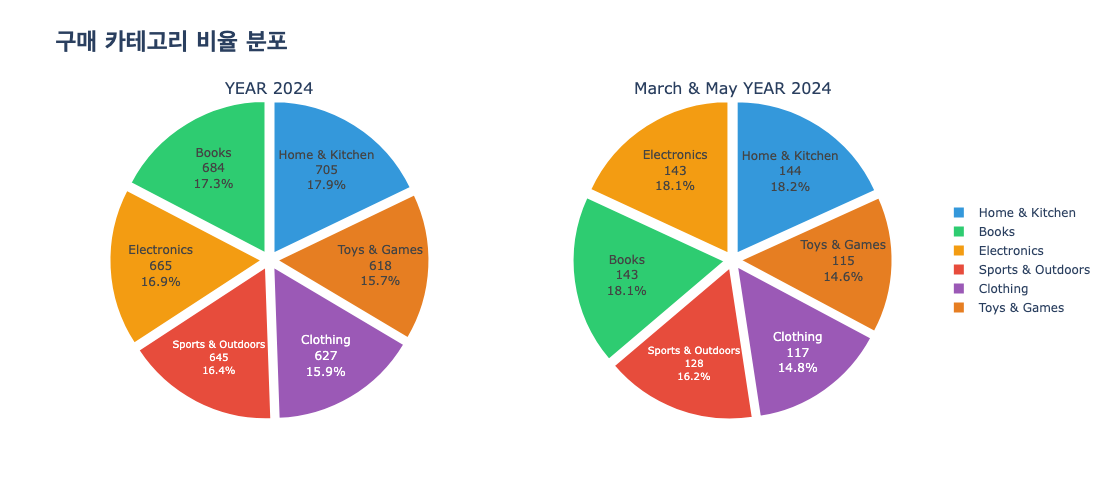

In [16]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 카테고리별 고정 색상 매핑
category_colors = {
    'Home & Kitchen': '#3498db',
    'Books': '#2ecc71',
    'Electronics': '#f39c12',
    'Sports & Outdoors': '#e74c3c',
    'Clothing': '#9b59b6',
    'Toys & Games': '#e67e22'
}

# 각 데이터프레임의 카테고리 순서대로 색상 리스트 생성
colors_2024 = [category_colors.get(cat, '#95a5a6') for cat in first_purchase_2024['Category']]
colors_high = [category_colors.get(cat, '#95a5a6') for cat in first_purchase_2024_high_retention['Category']]

fig = make_subplots(
    rows=1, cols=2, 
    subplot_titles=("YEAR 2024", "March & May YEAR 2024"),
    specs=[[{"type": "pie"}, {"type": "pie"}]]  
)

fig.add_trace(
    go.Pie(
        labels=first_purchase_2024['Category'],
        values=first_purchase_2024['orders_cnt_2024'],
        textinfo='label+percent+value',
        textposition='inside',
        insidetextorientation='horizontal',
        marker=dict(
            colors=colors_2024,  
            line=dict(color='white', width=2)
        ),
        hovertemplate='<b>%{label}</b><br>건수: %{value:,}<br>비율: %{percent}<extra></extra>',
        pull=[0.05] * len(first_purchase_2024)
    ),
    row=1, col=1
)

fig.add_trace(
    go.Pie(
        labels=first_purchase_2024_high_retention['Category'],
        values=first_purchase_2024_high_retention['order_cnt'],
        textinfo='label+percent+value',
        textposition='inside',
        insidetextorientation='horizontal',
        marker=dict(
            colors=colors_high, 
            line=dict(color='white', width=2)
        ),
        hovertemplate='<b>%{label}</b><br>건수: %{value:,}<br>비율: %{percent}<extra></extra>',
        pull=[0.05] * len(first_purchase_2024_high_retention)
    ),
    row=1, col=2
)

fig.update_layout(
    title=dict(
        text='<b>구매 카테고리 비율 분포</b>',
        font=dict(size=24)
    ),
    height=500,
    showlegend=True,
    legend=dict(
        orientation="v",
        yanchor="middle",
        y=0.5,
        xanchor="left",
        x=1.02
    )
)

fig.show()

## 가설 3: 카테고리 분포 비교 분석

### 가설
**리텐션이 높은 코호트의 카테고리 분포는 전체 코호트와 상이할 것이다.**

특정 카테고리를 선호하는 고객이 더 높은 재구매율을 보일 가능성이 있으며, 카테고리별 구매 패턴이 리텐션에 영향을 줄 수 있다.

---

### 분석 결과

#### 카테고리별 비교

| 카테고리 | 2024 전체 | 고리텐션 코호트 | 차이 | 증감률 |
|----------|-----------|----------------|------|--------|
| Home & Kitchen | 17.9% (705건) | 18.2% (144건) | +0.3%p | +1.7% |
| Books | 17.3% (684건) | 18.1% (143건) | +0.8%p | +4.6% |
| Electronics | 16.9% (665건) | 18.1% (143건) | **+1.2%p** | **+7.1%** |
| Sports & Outdoors | 16.4% (645건) | 16.2% (128건) | -0.2%p | -1.2% |
| Clothing | 15.9% (627건) | 14.8% (117건) | -1.1%p | -6.9% |
| Toys & Games | 15.7% (618건) | 14.6% (115건) | -1.1%p | -7.0% |

리텐션이 높은 코호트와 전체 코호트 간 카테고리 분포의 차이는 **매우 작음** (최대 1.2%p). 전반적인 카테고리 선호도 패턴이 거의 일치함.

---

### 가설 검증 결과

**가설 기각**

카테고리 분포는 유의미한 차이가 없으며, 최대 차이 1.2%p (증감률 7.1%)로 통계적으로 유의미하지 않음. 카테고리는 리텐션에 **직접적인 영향을 주는 주요 요인이 아님**으로 판단됨.


### 다음 단계

가설 3에서 전체 카테고리 분포가 차이를 설명하지 못하므로, 더 세밀한 분석 진행:

→ **가설 3-1: 첫 구매 카테고리 비교 분석** 

## 가설 3-1: 첫 구매 카테고리 비교 분석

### 가설
**리텐션이 높은 코호트의 첫 구매 카테고리 분포는 전체 코호트와 상이할 것이다.**

전체 카테고리 구매 패턴에서는 유의미한 차이가 확인되지 않았으므로, 고객의 **첫 구매 경험**에 초점을 맞춘다. 첫 구매 카테고리는 고객의 초기 경험을 형성하며, 이후 재구매 행동에 영향을 줄 수 있어 리텐션 차이를 설명하는 핵심 요인일 가능성이 있다.

In [17]:
# 2024년 첫 구매 카테고리 테이블 생성
query_first_category_2024 = """
WITH first_purchase AS (
	SELECT 
		CustomerID,
        MIN(OrderDate) AS first_purchase_date,
        DATE_FORMAT(MIN(OrderDate), "%Y-%m") AS first_purchase_month
	FROM orders_info
    GROUP BY CustomerID
),

first_purchase_2024 AS (
	SELECT 
		CustomerID,
        first_purchase_date
    FROM first_purchase
    WHERE YEAR(first_purchase_date) = 2024
)

SELECT 
	o.Category AS Category,
    COUNT(*) AS orders_cnt_2024
FROM first_purchase_2024 f24
JOIN orders_info o ON o.CustomerID = f24.CustomerID
AND f24.first_purchase_date = o.OrderDate
GROUP BY o.Category
ORDER BY orders_cnt_2024 DESC;
"""    

# 리텐션이 높은 코호트의 첫 구매 카테고리 테이블 생성
query_first_category_high_retention_2024 = """
WITH first_purchase AS (
	SELECT
        CustomerID,
        MIN(OrderDate) AS first_purchase_date,
        DATE_FORMAT(MIN(OrderDate), "%Y-%m") AS first_purchase_month
	FROM orders_info
    GROUP BY CustomerID
),

first_purchase_2024 AS (
	SELECT 
		CustomerID,
        first_purchase_date
    FROM first_purchase
    WHERE first_purchase_month IN ('2024-03', '2024-05')
)

SELECT 
	o.Category AS Category,
    COUNT(*) AS order_cnt
FROM first_purchase_2024 f24
JOIN orders_info o ON o.CustomerID = f24.CustomerID
AND f24.first_purchase_date = o.OrderDate
GROUP BY o.Category
ORDER BY order_cnt DESC;
"""

first_category_2024 = pd.read_sql(query_first_category_2024, engine)
first_category_high_retention_2024 = pd.read_sql(query_first_category_high_retention_2024, engine)

In [18]:
first_category_2024

,Category,orders_cnt_2024
0,Home & Kitchen,579
1,Books,565
2,Sports & Outdoors,541
3,Electronics,541
4,Toys & Games,519
5,Clothing,518


In [19]:
first_category_high_retention_2024

,Category,order_cnt
0,Books,108
1,Electronics,107
2,Home & Kitchen,105
3,Sports & Outdoors,104
4,Toys & Games,88
5,Clothing,85


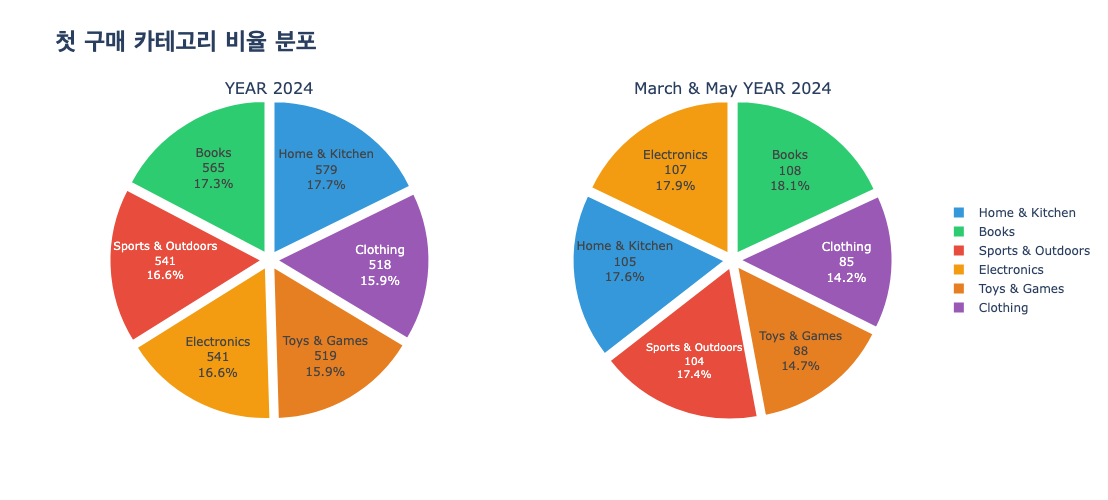

In [21]:
# 카테고리별 고정 색상 매핑
category_colors = {
    'Home & Kitchen': '#3498db',
    'Books': '#2ecc71',
    'Electronics': '#f39c12',
    'Sports & Outdoors': '#e74c3c',
    'Clothing': '#9b59b6',
    'Toys & Games': '#e67e22'
}

# 각 데이터프레임의 카테고리 순서대로 색상 리스트 생성
colors_2024 = [category_colors.get(cat, '#95a5a6') for cat in first_category_2024['Category']]
colors_high = [category_colors.get(cat, '#95a5a6') for cat in first_category_high_retention_2024['Category']]

fig = make_subplots(
    rows=1, cols=2, 
    subplot_titles=("YEAR 2024", "March & May YEAR 2024"),
    specs=[[{"type": "pie"}, {"type": "pie"}]]  
)

fig.add_trace(
    go.Pie(
        labels=first_category_2024['Category'],
        values=first_category_2024['orders_cnt_2024'],
        textinfo='label+percent+value',
        textposition='inside',
        insidetextorientation='horizontal',
        marker=dict(
            colors=colors_2024,  
            line=dict(color='white', width=2)
        ),
        hovertemplate='<b>%{label}</b><br>건수: %{value:,}<br>비율: %{percent}<extra></extra>',
        pull=[0.05] * len(first_category_2024)
    ),
    row=1, col=1
)

fig.add_trace(
    go.Pie(
        labels=first_category_high_retention_2024['Category'],
        values=first_category_high_retention_2024['order_cnt'],
        textinfo='label+percent+value',
        textposition='inside',
        insidetextorientation='horizontal',
        marker=dict(
            colors=colors_high, 
            line=dict(color='white', width=2)
        ),
        hovertemplate='<b>%{label}</b><br>건수: %{value:,}<br>비율: %{percent}<extra></extra>',
        pull=[0.05] * len(first_category_high_retention_2024)
    ),
    row=1, col=2
)

fig.update_layout(
    title=dict(
        text='<b>첫 구매 카테고리 비율 분포</b>',
        font=dict(size=24)
    ),
    height=500,
    showlegend=True,
    legend=dict(
        orientation="v",
        yanchor="middle",
        y=0.5,
        xanchor="left",
        x=1.02
    )
)

fig.show()

## 가설 3-1: 첫 구매 카테고리 비교 분석

### 가설
**리텐션이 높은 코호트의 첫 구매 카테고리는 전체 코호트와 상이할 것이다.**

첫 구매 경험이 재구매에 영향을 줄 수 있으며, 특정 카테고리로 시작한 고객이 더 높은 재구매율을 보일 가능성이 있다.

---

### 분석 결과

#### 첫 구매 카테고리별 비교

| 카테고리 | 2024 전체 | 고리텐션 코호트 | 차이 | 증감률 |
|----------|-----------|----------------|------|--------|
| Books | 17.3% (565명) | 18.1% (108명) | +0.8%p | +4.6% |
| Home & Kitchen | 17.7% (579명) | 17.6% (105명) | -0.1%p | -0.6% |
| Sports & Outdoors | 16.6% (541명) | 17.4% (104명) | +0.8%p | +4.8% |
| Electronics | 16.6% (541명) | 17.9% (107명) | **+1.3%p** | **+7.8%** |
| Toys & Games | 15.9% (519명) | 14.7% (88명) | -1.2%p | -7.5% |
| Clothing | 15.9% (518명) | 14.2% (85명) | **-1.7%p** | **-10.7%** |

리텐션이 높은 코호트와 전체 코호트 간 첫 구매 카테고리 분포의 차이는 **매우 작음** (최대 1.7%p). 첫 구매 경험도 전체 구매 패턴과 유사함.

---

### 가설 검증 결과

**가설 기각**

첫 구매 카테고리 분포는 유의미한 차이가 없으며, 최대 차이 1.7%p (증감률 10.7%)로 통계적으로 유의미하지 않음. 첫 구매 카테고리는 리텐션에 **직접적인 영향을 주는 주요 요인이 아님**으로 판단됨.

---

### 다음 단계

가설 3-1 역시 전체 카테고리 분포가 차이를 설명하지 못하므로, 더 세밀한 분석 진행:

→ **가설 3-1-1: 첫 구매 카테고리별 재구매율 비교 분석** 

## 가설 3-1-1: 첫 구매 카테고리별 재구매율 비교 분석

### 가설
**특정 카테고리를 첫 구매한 고객이 전체적으로 더 높은 재구매율을 보일 것이다.**

- 첫 구매 경험이 이후 재구매 행동에 영향을 줄 수 있으며, 특정 카테고리로 시작한 고객이 충성 고객으로 전환될 확률이 더 높을 가능성이 있다.

전체 카테고리 분포 및 첫 구매 카테고리에서는 유의미한 차이가 확인되지 않았으므로, 특정 카테고리 구매 경험이 전체 재구매율에 미치는 영향을 확인하고자 한다. 즉, 어떤 카테고리가 고객을 충성 고객으로 전환시키는 데 효과적인지 검증한다.

In [30]:
# 2024년 전체
query_category_2024 = """
-- Q. 카테고리별 첫 구매 경험이 재구매에(모든 카테고리에 대해) 영향을 주는가?
-- 1. 고객별 첫  주문 데이터 생성  
-- 2. 2024년 주문 데이터만 추출
-- 3. 각 고객의 첫 구매 카테고리 추출
-- 4. 재구매 여부 확인(주문 횟수가 2이상인 경우 재구매, 2미만이면 1번만 주문)
-- 5. 카테고리, 총 고객수, 재구매 고객수, 재구매 비율 불러오기

WITH first_purchase AS (
	SELECT
		CustomerID,
        MIN(OrderDate) AS first_purchase_date
	FROM orders_info
    GROUP BY CustomerID
),

customer_2024 AS (
	SELECT 
		CustomerID,
        first_purchase_date
	FROM first_purchase
    WHERE YEAR(first_purchase_date) = 2024
),

first_purchase_category AS (
	SELECT
		o.CustomerID,
        o.Category AS first_category
	FROM customer_2024 c
    JOIN orders_info o ON o.CustomerID = c.CustomerID
					   AND o.OrderDate = c.first_purchase_date
),

repurchase_status AS (
    SELECT
        o.CustomerID,
        CASE WHEN COUNT(*) > 0 THEN 1 ELSE 0 END AS is_repurchased
    FROM orders_info o
    INNER JOIN customer_2024 c ON o.CustomerID = c.CustomerID
    WHERE o.OrderDate > c.first_purchase_date
    GROUP BY o.CustomerID
)

SELECT 
    fpc.first_category,
    COUNT(fpc.CustomerID) AS total_customers,
    SUM(rs.is_repurchased) AS repurchased_customers,
    ROUND(SUM(rs.is_repurchased) * 100 / COUNT(fpc.CustomerID), 2) AS retention_rate
FROM first_purchase_category fpc
LEFT JOIN repurchase_status rs ON rs.CustomerID = fpc.CustomerID  
GROUP BY fpc.first_category;
"""

# 2024년 3월 / 5월
query_category_2024_high_retention = """
WITH first_purchase AS (
	SELECT
		CustomerID,
        MIN(OrderDate) AS first_purchase_date
	FROM orders_info
    GROUP BY CustomerID
),

customer_2024 AS (
	SELECT 
		CustomerID,
        first_purchase_date
	FROM first_purchase
    WHERE YEAR(first_purchase_date) = 2024 
    AND (MONTH(first_purchase_date) = 3 OR MONTH(first_purchase_date) = 5)
),

first_purchase_category AS (
	SELECT
		o.CustomerID,
        o.Category AS first_category
	FROM customer_2024 c
    JOIN orders_info o ON o.CustomerID = c.CustomerID
					   AND o.OrderDate = c.first_purchase_date
),

repurchase_status AS (
    SELECT
        o.CustomerID,
        CASE WHEN COUNT(*) > 0 THEN 1 ELSE 0 END AS is_repurchased
    FROM orders_info o
    INNER JOIN customer_2024 c ON o.CustomerID = c.CustomerID
    WHERE o.OrderDate > c.first_purchase_date
    GROUP BY o.CustomerID
)

SELECT 
    fpc.first_category,
    COUNT(fpc.CustomerID) AS total_customers,
    SUM(rs.is_repurchased) AS repurchased_customers,
    ROUND(SUM(rs.is_repurchased) * 100 / COUNT(fpc.CustomerID), 2) AS retention_rate
FROM first_purchase_category fpc
LEFT JOIN repurchase_status rs ON rs.CustomerID = fpc.CustomerID  
GROUP BY fpc.first_category;
"""

retention_category_2024 = pd.read_sql(query_category_2024, engine)
retention_category_2024['repurchased_customers'] = retention_category_2024['repurchased_customers'].astype(int)


high_retention_category_2024 = pd.read_sql(query_category_2024_high_retention, engine)
high_retention_category_2024['repurchased_customers'] = high_retention_category_2024['repurchased_customers'].astype(int)

In [31]:
retention_category_2024

,first_category,total_customers,repurchased_customers,retention_rate
0,Sports & Outdoors,541,97,17.93
1,Home & Kitchen,579,108,18.65
2,Toys & Games,519,99,19.08
3,Electronics,541,98,18.11
4,Books,565,104,18.41
5,Clothing,518,106,20.46


In [32]:
high_retention_category_2024

,first_category,total_customers,repurchased_customers,retention_rate
0,Electronics,107,27,25.23
1,Books,108,32,29.63
2,Toys & Games,88,29,32.95
3,Sports & Outdoors,104,29,27.88
4,Home & Kitchen,105,37,35.24
5,Clothing,85,18,21.18


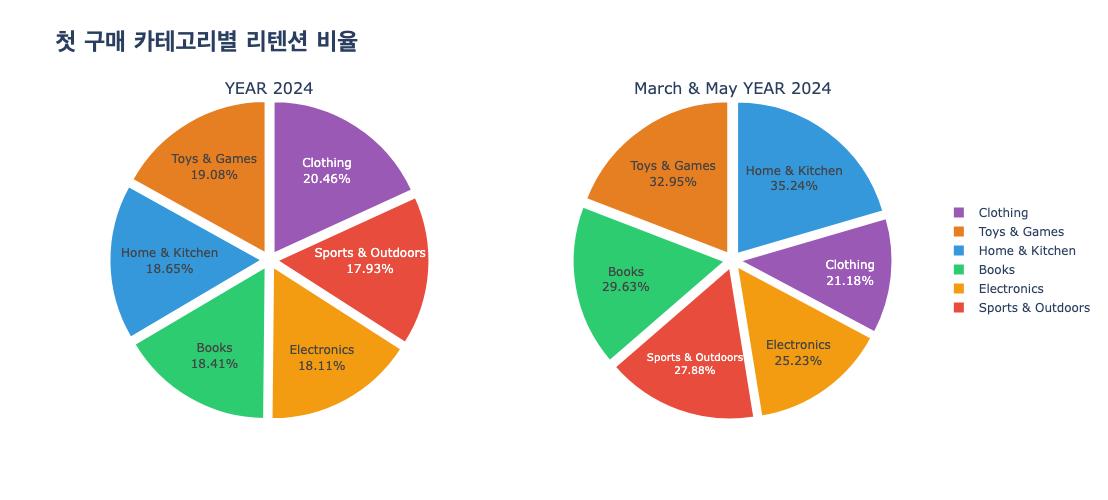

In [41]:
# 카테고리별 고정 색상 매핑
category_colors = {
    'Home & Kitchen': '#3498db',
    'Books': '#2ecc71',
    'Electronics': '#f39c12',
    'Sports & Outdoors': '#e74c3c',
    'Clothing': '#9b59b6',
    'Toys & Games': '#e67e22'
}

# 각 데이터프레임의 카테고리 순서대로 색상 리스트 생성
colors_2024 = [category_colors.get(cat, '#95a5a6') for cat in retention_category_2024['first_category']]
colors_high = [category_colors.get(cat, '#95a5a6') for cat in high_retention_category_2024['first_category']]

fig = make_subplots(
    rows=1, cols=2, 
    subplot_titles=("YEAR 2024", "March & May YEAR 2024"),
    specs=[[{"type": "pie"}, {"type": "pie"}]]  
)

fig.add_trace(
    go.Pie(
        labels=retention_category_2024['first_category'],
        values=retention_category_2024['retention_rate'],
        texttemplate='%{label}<br>%{value:.2f}%',
        textinfo='label+value',
        textposition='inside',
        insidetextorientation='horizontal',
        marker=dict(
            colors=colors_2024,  
            line=dict(color='white', width=2)
        ),
        hovertemplate='<b>%{label}</b><br>건수: %{value:,}<br>비율: %{percent}<extra></extra>',
        pull=[0.05] * len(first_category_2024)
    ),
    row=1, col=1
)

fig.add_trace(
    go.Pie(
        labels=high_retention_category_2024['first_category'],
        values=high_retention_category_2024['retention_rate'],
        texttemplate='%{label}<br>%{value:.2f}%',
        textinfo='label+value',
        textposition='inside',
        insidetextorientation='horizontal',
        marker=dict(
            colors=colors_high, 
            line=dict(color='white', width=2)
        ),
        hovertemplate='<b>%{label}</b><br>건수: %{value:,}<br>비율: %{percent}<extra></extra>',
        pull=[0.05] * len(high_retention_category_2024)
    ),
    row=1, col=2
)

fig.update_layout(
    title=dict(
        text='<b>첫 구매 카테고리별 리텐션 비율</b>',
        font=dict(size=24)
    ),
    height=500,
    showlegend=True,
    legend=dict(
        orientation="v",
        yanchor="middle",
        y=0.5,
        xanchor="left",
        x=1.02
    )
)

fig.show()

## 가설 3-1-1: 첫 구매 카테고리별 재구매율 비교 분석

### 가설
**특정 카테고리를 첫 구매한 고객이 전체적으로 더 높은 재구매율을 보일 것이다.**

첫 구매 경험이 이후 재구매 행동에 영향을 줄 수 있으며, 특정 카테고리로 시작한 고객이 충성 고객으로 전환될 확률이 더 높을 가능성이 있다.

---

### 분석 결과

#### 카테고리별 재구매율 비교

| 카테고리 | 2024 전체 | 고리텐션 코호트 | 차이 | 증감률 |
|----------|-----------|----------------|------|--------|
| Home & Kitchen | 18.65% | 35.24% | **+16.59%p** | **+88.9%** |
| Toys & Games | 19.08% | 32.95% | **+13.87%p** | **+72.7%** |
| Books | 18.41% | 29.63% | **+11.22%p** | **+60.9%** |
| Sports & Outdoors | 17.93% | 27.88% | +9.95%p | +55.5% |
| Electronics | 18.11% | 25.23% | +7.12%p | +39.3% |
| Clothing | 20.46% | 21.18% | +0.72%p | +3.5% |

---

### 가설 검증 결과

**✅ 부분 채택**

첫 구매 카테고리에 따라 재구매율의 **유의미한 차이가 존재한다.** 특히 **Home & Kitchen, Toys & Games, Books**로 시작한 고객의 재구매율이 월등히 높음 (30~35%).

---

### 핵심 발견

**1. 첫 구매 경험이 재구매율의 핵심 요인**
- 전체 카테고리 분포/첫 구매 카테고리 분포: 차이 없음 
- 첫 구매 카테고리별 재구매율: 유의미한 차이 존재
- **의미:** "어떤 카테고리를 사는가"보다 **"첫 경험으로 어떤 카테고리를 사는가"** 가 재구매율에 결정적 영향

**2. 카테고리 Type 구분**
- **고재구매 (30~35%):** Home & Kitchen, Toys & Games, Books → 소모성/반복 구매
- **저재구매 (21~25%):** Electronics, Clothing → 내구재/일회성 구매

---

## 💡 제언

### 신규 고객 첫 구매 카테고리 유도 전략

첫 구매 카테고리가 재구매율을 결정하므로, 신규 고객이 **고재구매 카테고리**로 첫 구매하도록 유도한다.

---

**1. 신규 고객 첫 구매 유도**

웰컴 쿠폰 전략적 배포
- 신규 가입 시 Home & Kitchen, Toys & Games, Books 전용 20% 할인 쿠폰
- 쿠폰 유효기간 7일로 빠른 첫 구매 유도

랜딩 페이지 최적화
- 신규 고객 첫 페이지에 고재구매 카테고리 우선 노출
- "첫 구매 추천" 섹션 배치

온보딩 개인화
- 가입 시 관심 카테고리 설문 → 고재구매 카테고리 선택 시 추가 쿠폰

---

**2. 고재구매 카테고리 재구매 강화**

정기 구독 서비스
- Home & Kitchen: 주방 소모품 월 1회 자동 배송 (15% 할인)
- Books: 신간 월 1회 큐레이션 배송
- Toys & Games: 시리즈 제품 출시 시 자동 알림 + 사전 예약 할인

재구매 타이밍 알림
- 구매 후 30일, 60일 시점 자동 쿠폰 발송
- 카테고리별 맞춤 추천

묶음 할인
- 3개 이상 구매 시 20% 할인 + 무료배송

---

**3. 저재구매 카테고리 크로스셀링**

다른 카테고리 유도
- Electronics/Clothing 구매 고객 → Home & Kitchen, Books 크로스셀링
- 첫 구매 후 7일 시점 "다른 카테고리 10% 쿠폰" 발송

액세서리 판매
- Electronics: 케이블, 케이스 2+1 프로모션
- Clothing: 코디 아이템 추천

---

### 최종 결론

리텐션은 단순히 “무엇을 구매했는가”가 아니라  
**“처음 어떤 경험으로 시작했는가”에 의해 크게 좌우된다.**

따라서 신규 고객의 첫 구매 카테고리를 전략적으로 설계하는 것이  
리텐션을 높이는 가장 직접적인 레버리지이다.